# Import the Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


# Loading the dataset

In [2]:


# Load the dataset
df = pd.read_csv('PCOS_top_15.csv')

# Removing duplicates
df_cleaned = df.drop_duplicates()

# Removing extreme outliers in LH and FSH/LH for modeling stability
# Using the 99th percentile as a threshold
q_lh = df_cleaned['LH(mIU/mL)'].quantile(0.99)
q_fshlh = df_cleaned['FSH/LH'].quantile(0.99)

df_cleaned = df_cleaned[df_cleaned['LH(mIU/mL)'] < q_lh]
df_cleaned = df_cleaned[df_cleaned['FSH/LH'] < q_fshlh]

print(f"Original shape: {df.shape}, Cleaned shape: {df_cleaned.shape}")
df.head()

Original shape: (541, 16), Cleaned shape: (529, 16)


,PCOS (Y/N),Follicle No. (R),Follicle No. (L),Skin darkening (Y/N),hair growth(Y/N),Weight gain(Y/N),AMH(ng/mL),Cycle(R/I),Cycle length(days),Fast food (Y/N),LH(mIU/mL),FSH/LH,Age (yrs),BMI,Weight (Kg),Hip(inch)
0,0,3,3,0,0,0,2.07,2,5,1,3.68,2.16,28,19.3,44.6,36
1,0,5,3,0,0,0,1.53,2,5,0,1.09,6.17,36,24.9,65.0,38
2,1,15,13,0,0,0,6.63,2,5,1,0.88,6.30,33,25.3,68.8,40
3,0,2,2,0,0,0,1.22,2,5,0,2.36,3.42,37,29.7,65.0,42
4,0,4,3,0,0,0,2.26,2,5,0,0.90,4.42,25,20.1,52.0,37


In [3]:
#Statistical Summary
df_cleaned.describe()

,PCOS (Y/N),Follicle No. (R),Follicle No. (L),Skin darkening (Y/N),hair growth(Y/N),Weight gain(Y/N),AMH(ng/mL),Cycle(R/I),Cycle length(days),Fast food (Y/N),LH(mIU/mL),FSH/LH,Age (yrs),BMI,Weight (Kg),Hip(inch)
count,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000,529.000000
mean,0.323251,6.642722,6.126654,0.310019,0.274102,0.378072,5.536187,2.550095,4.947070,0.512287,2.671898,3.505123,31.413989,24.291493,59.616824,37.973535
std,0.468161,4.454202,4.259240,0.462939,0.446483,0.485365,5.770124,0.897094,1.485101,0.500322,2.087995,3.945103,5.409436,4.049100,11.064504,3.998965
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,2.000000,0.000000,0.000000,0.100000,0.230000,20.000000,12.400000,31.000000,26.000000
25%,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,2.000000,2.000000,5.000000,0.000000,1.030000,1.450000,27.000000,21.600000,52.000000,36.000000
50%,0.000000,6.000000,5.000000,0.000000,0.000000,0.000000,3.700000,2.000000,5.000000,1.000000,2.260000,2.170000,31.000000,24.200000,59.600000,38.000000
75%,1.000000,10.000000,9.000000,1.000000,1.000000,1.000000,6.740000,4.000000,5.000000,1.000000,3.620000,3.870000,35.000000,26.700000,65.000000,40.000000
max,1.000000,20.000000,22.000000,1.000000,1.000000,1.000000,66.000000,5.000000,12.000000,1.000000,10.500000,29.730000,48.000000,38.900000,108.000000,48.000000


In [4]:
#Checking datatypes of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PCOS (Y/N)            541 non-null    int64  
 1   Follicle No. (R)      541 non-null    int64  
 2   Follicle No. (L)      541 non-null    int64  
 3   Skin darkening (Y/N)  541 non-null    int64  
 4   hair growth(Y/N)      541 non-null    int64  
 5   Weight gain(Y/N)      541 non-null    int64  
 6   AMH(ng/mL)            541 non-null    float64
 7   Cycle(R/I)            541 non-null    int64  
 8   Cycle length(days)    541 non-null    int64  
 9   Fast food (Y/N)       541 non-null    int64  
 10  LH(mIU/mL)            541 non-null    float64
 11  FSH/LH                541 non-null    float64
 12  Age (yrs)             541 non-null    int64  
 13  BMI                   541 non-null    float64
 14  Weight (Kg)           541 non-null    float64
 15  Hip(inch)             5

# Exploratory Data Analysis (EDA)

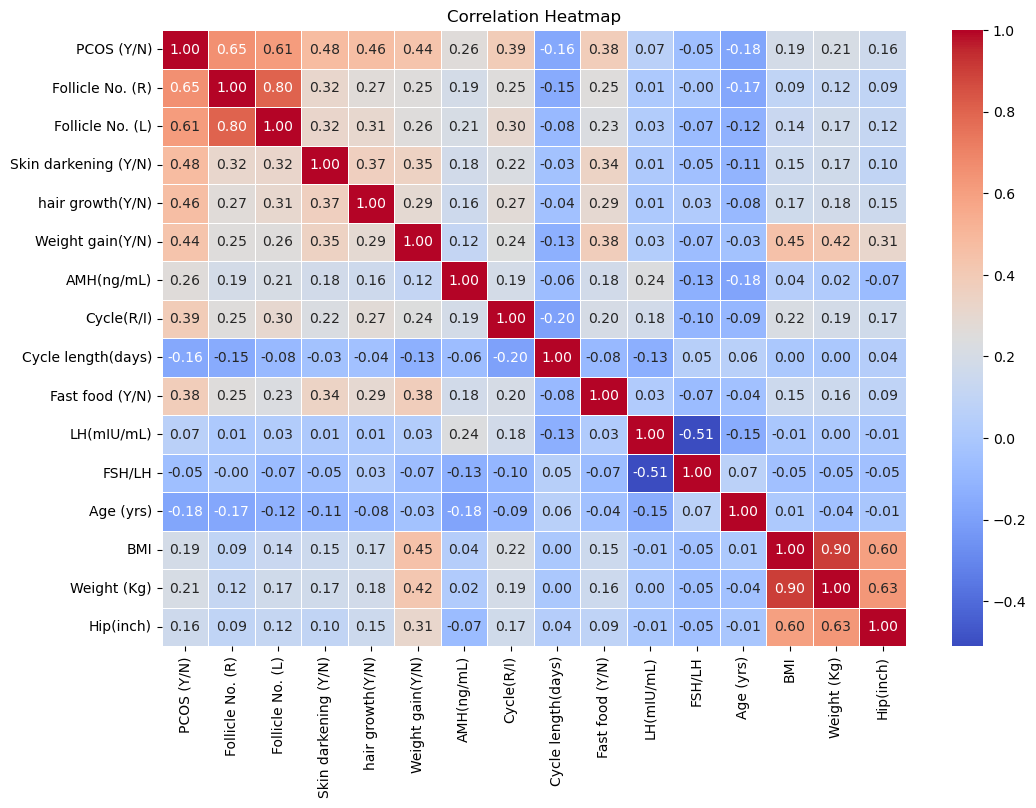



In this heatmap, I’m looking at how each feature relates to a PCOS diagnosis. Here are my key takeaways

Primary Drivers: The strongest predictors are Follicle Counts (Right and Left), with correlation coefficients above 0.60. This confirms that the ultrasound findings are the most significant markers for PCOS in this dataset.

Clinical Symptoms: There is a clear positive correlation between PCOS and physical signs like Skin Darkening, Hair Growth, and Weight Gain. This shows that these symptoms are reliable clinical indicators of the condition.

Lifestyle & Cycles: Factors like Fast Food consumption and Irregular Cycles also show a notable positive tie to the diagnosis, while Age shows a slight negative correlation, suggesting the condition is more frequently recorded in the younger age groups within this data.

Data Redundancy (Multicollinearity): I noticed very high correlations between Weight and BMI (0.90) and between the Left and Right Follicle counts (0.80). This tells me that

In [5]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_cleaned.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()
print("\n\nIn this heatmap, I’m looking at how each feature relates to a PCOS diagnosis. Here are my key takeaways")
print("\nPrimary Drivers: The strongest predictors are Follicle Counts (Right and Left), with correlation coefficients above 0.60. This confirms that the ultrasound findings are the most significant markers for PCOS in this dataset.")
print("\nClinical Symptoms: There is a clear positive correlation between PCOS and physical signs like Skin Darkening, Hair Growth, and Weight Gain. This shows that these symptoms are reliable clinical indicators of the condition.")
print("\nLifestyle & Cycles: Factors like Fast Food consumption and Irregular Cycles also show a notable positive tie to the diagnosis, while Age shows a slight negative correlation, suggesting the condition is more frequently recorded in the younger age groups within this data.")
print("\nData Redundancy (Multicollinearity): I noticed very high correlations between Weight and BMI (0.90) and between the Left and Right Follicle counts (0.80). This tells me that some features are providing nearly identical information, which is something I need to manage to keep the model efficient.")

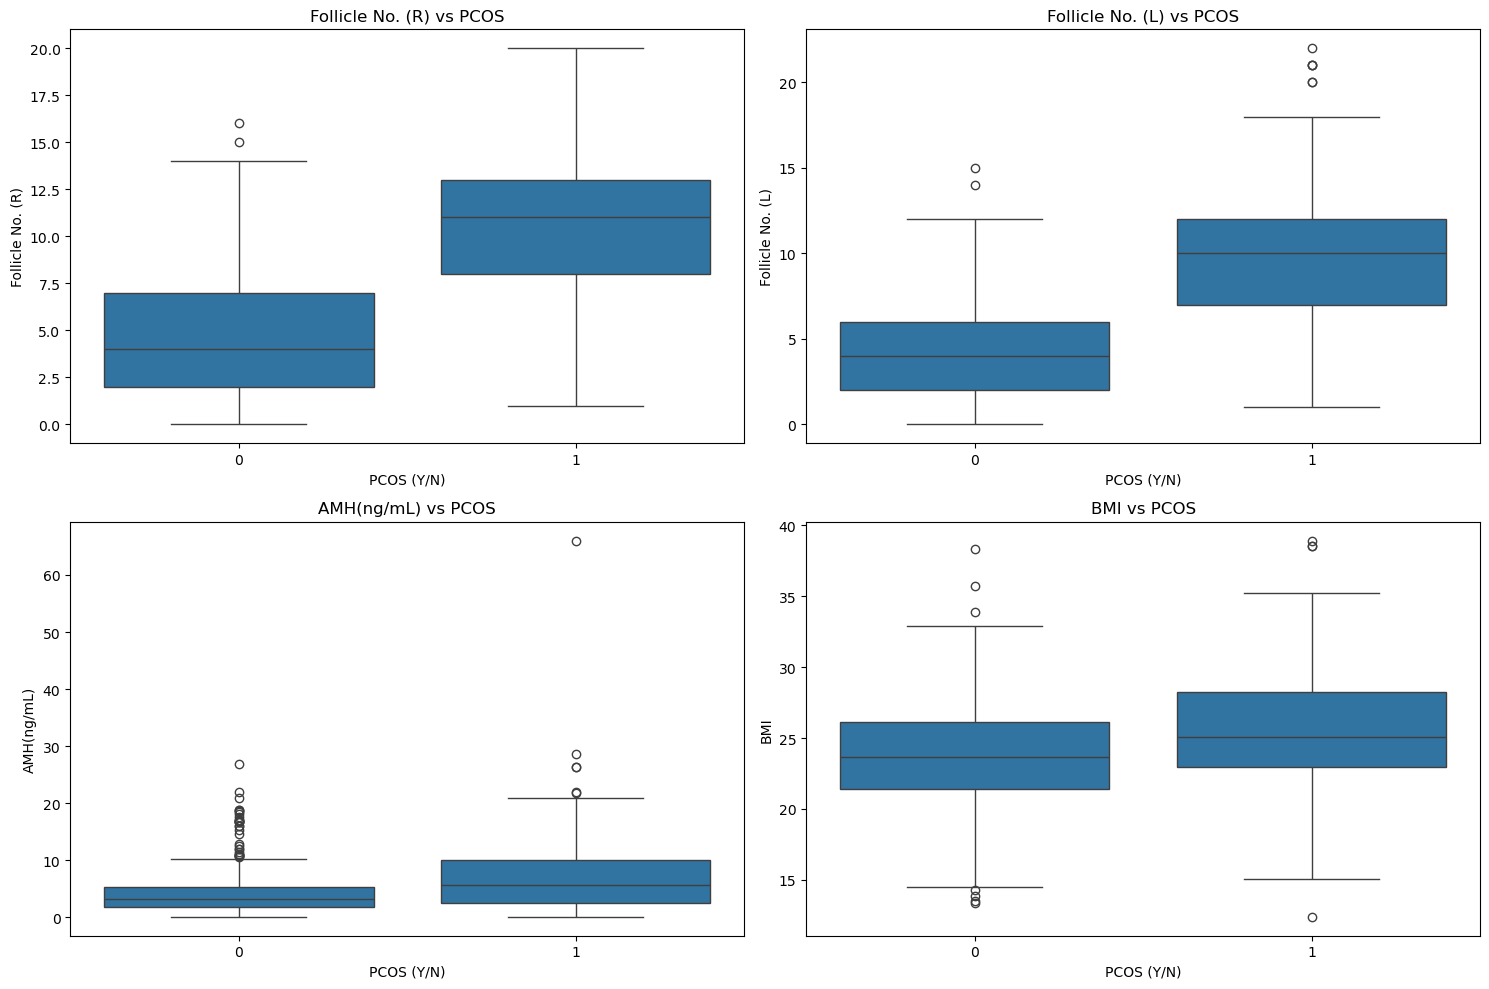

'The boxplots reveal a striking visual distinction between the PCOS and non-PCOS groups, particularly in ovarian and metabolic markers. There is a clear, significant separation in Follicle Counts for both the right and left ovaries, where the median count for PCOS patients is nearly double that of the healthy group, marking them as the most reliable diagnostic features. Similarly, AMH levels show a visible upward shift in the PCOS group, which is medically expected as high AMH correlates with a high number of follicles. We also see that BMI distributions are higher for positive cases, reinforcing the link between body mass and the condition, although there is some overlap between the groups. While there are several outliers in the AMH and BMI data, the overall trend remains consistently higher for the PCOS group. The relatively tight interquartile ranges, especially for follicle counts, suggest these variables are stable and precise predictors. Ultimately, these plots provide strong vi

In [6]:
# Boxplots for key features vs PCOS target
key_features = ['Follicle No. (R)', 'Follicle No. (L)', 'AMH(ng/mL)', 'BMI']
plt.figure(figsize=(15, 10))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='PCOS (Y/N)', y=col, data=df_cleaned)
    plt.title(f'{col} vs PCOS')
plt.tight_layout()
plt.show()
'''The boxplots reveal a striking visual distinction between the PCOS and non-PCOS groups, particularly in ovarian and metabolic markers. There is a clear, significant separation in Follicle Counts for both the right and left ovaries, where the median count for PCOS patients is nearly double that of the healthy group, marking them as the most reliable diagnostic features. Similarly, AMH levels show a visible upward shift in the PCOS group, which is medically expected as high AMH correlates with a high number of follicles. We also see that BMI distributions are higher for positive cases, reinforcing the link between body mass and the condition, although there is some overlap between the groups. While there are several outliers in the AMH and BMI data, the overall trend remains consistently higher for the PCOS group. The relatively tight interquartile ranges, especially for follicle counts, suggest these variables are stable and precise predictors. Ultimately, these plots provide strong visual evidence that ovarian and hormonal features are the primary differentiators in identifying the condition.'''

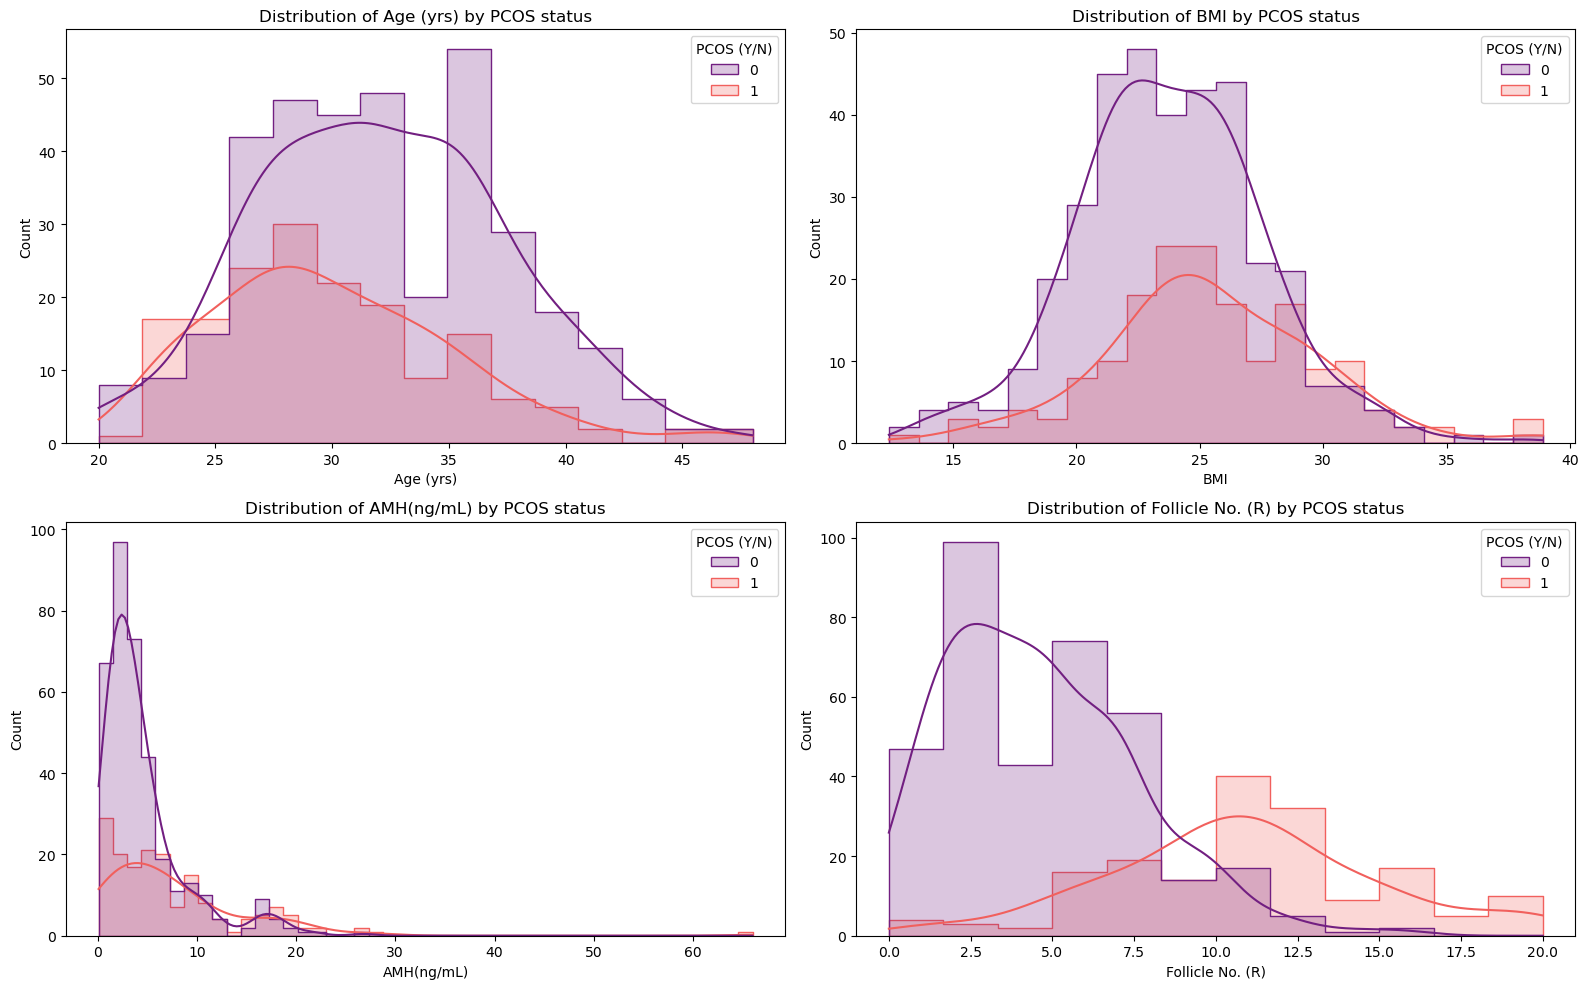

'Interpretation: When looking at these distribution curves, it’s clear that PCOS cases are heavily skewed towards higher AMH levels and Follicle counts. While the Age distribution is fairly similar for both groups, the BMI curve for PCOS patients is shifted to the right, showing that higher BMI is a significant risk factor, though there is still some overlap with the healthy group.'

In [7]:
#KDE plots of key features

cols_to_plot = ['Age (yrs)', 'BMI', 'AMH(ng/mL)', 'Follicle No. (R)']
plt.figure(figsize=(16, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df_cleaned, x=col, hue='PCOS (Y/N)', kde=True, element='step', palette='magma')
    plt.title(f'Distribution of {col} by PCOS status')
plt.tight_layout()
plt.show()

'''Interpretation: When looking at these distribution curves, it’s clear that PCOS cases are heavily skewed towards higher AMH levels and Follicle counts. While the Age distribution is fairly similar for both groups, the BMI curve for PCOS patients is shifted to the right, showing that higher BMI is a significant risk factor, though there is still some overlap with the healthy group.'''

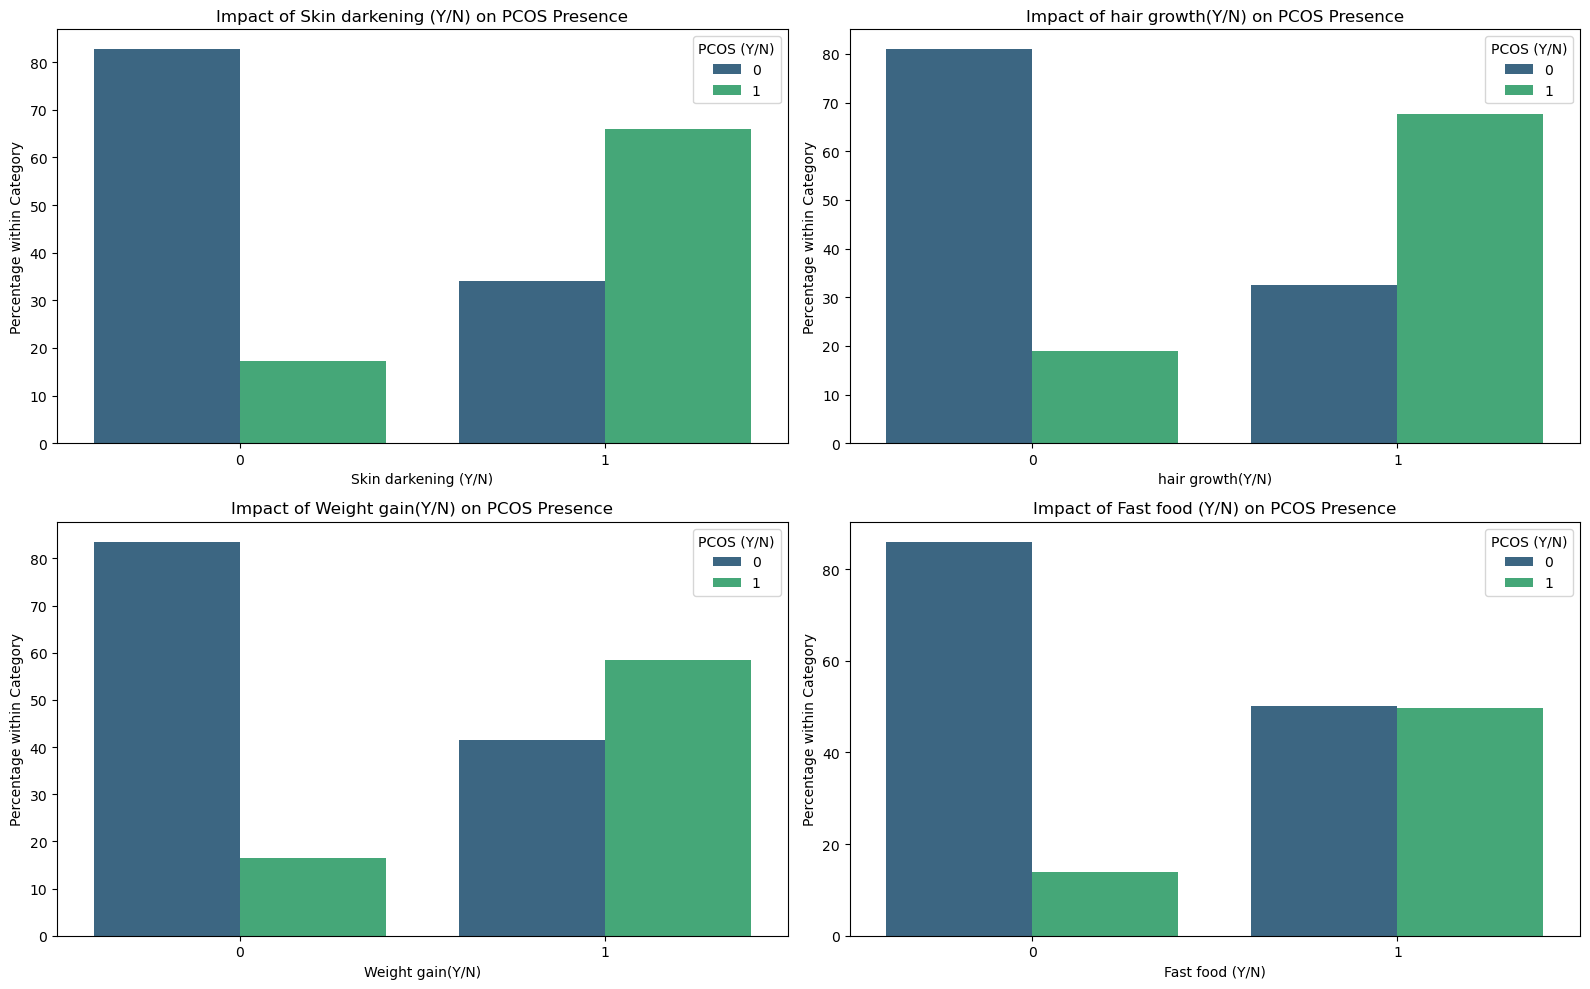

"Interpretation: These bar charts reveal just how predictive the physical symptoms are. For instance, in the group of patients who reported Skin Darkening or Hair Growth, the percentage of PCOS cases is drastically higher compared to those without these symptoms. It’s also interesting to see that Fast Food consumption shows a visible correlation, where 'Yes' respondents have a much higher frequency of PCOS."

In [8]:
#Grouped bar charts of categorical columns
categorical_flags = ['Skin darkening (Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Fast food (Y/N)']
plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_flags, 1):
    plt.subplot(2, 2, i)
    # Using percentages for a fair comparison
    temp_df = df_cleaned.groupby([col, 'PCOS (Y/N)']).size().reset_index(name='count')
    total = temp_df.groupby(col)['count'].transform('sum')
    temp_df['percentage'] = (temp_df['count'] / total) * 100
    
    sns.barplot(data=temp_df, x=col, y='percentage', hue='PCOS (Y/N)', palette='viridis')
    plt.title(f'Impact of {col} on PCOS Presence')
    plt.ylabel('Percentage within Category')
plt.tight_layout()
plt.show()
'''Interpretation: These bar charts reveal just how predictive the physical symptoms are. For instance, in the group of patients who reported Skin Darkening or Hair Growth, the percentage of PCOS cases is drastically higher compared to those without these symptoms. It’s also interesting to see that Fast Food consumption shows a visible correlation, where 'Yes' respondents have a much higher frequency of PCOS.'''

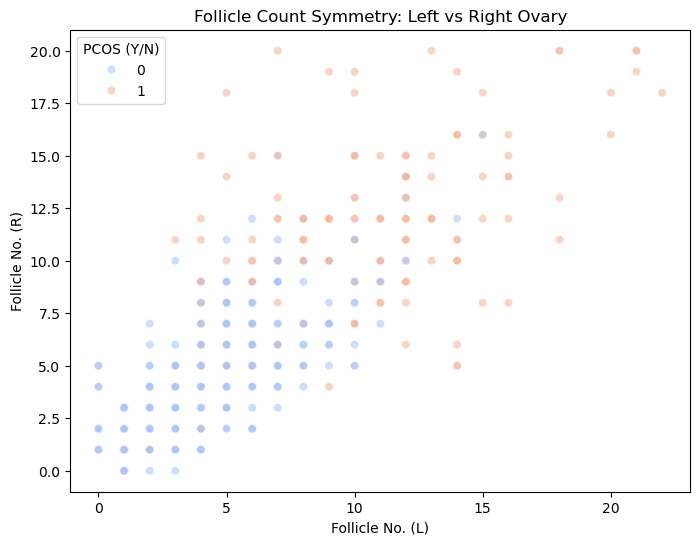

"Interpretation: This scatter plot shows a very strong linear relationship between the Left and Right Follicle counts, proving that both ovaries typically develop follicles at a similar rate. More importantly, you can see a clear 'cluster' in the top-right corner; once the follicle count in both ovaries crosses a certain threshold (around 8-10), nearly every single data point belongs to a PCOS patient, creating a very distinct diagnostic zone."

In [9]:
#Scatter plot for ovarian symmetry analysis
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cleaned, x='Follicle No. (L)', y='Follicle No. (R)', hue='PCOS (Y/N)', alpha=0.6, palette='coolwarm')
plt.title('Follicle Count Symmetry: Left vs Right Ovary')
plt.show()
'''Interpretation: This scatter plot shows a very strong linear relationship between the Left and Right Follicle counts, proving that both ovaries typically develop follicles at a similar rate. More importantly, you can see a clear 'cluster' in the top-right corner; once the follicle count in both ovaries crosses a certain threshold (around 8-10), nearly every single data point belongs to a PCOS patient, creating a very distinct diagnostic zone.'''

# Performing Statistical Tests


In [10]:
from scipy.stats import ttest_ind, chi2_contingency

# Function to run tests
def run_stat_tests(df, target):
    results = []
    cont_feats = ['Follicle No. (R)', 'Follicle No. (L)', 'AMH(ng/mL)', 'BMI', 'Age (yrs)']
    cat_feats = ['Skin darkening (Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)']

    # Continuous: T-Test
    for col in cont_feats:
        stat, p = ttest_ind(df[df[target]==0][col], df[df[target]==1][col])
        results.append({'Feature': col, 'Test': 'T-Test', 'P-Value': p})

    # Categorical: Chi-Square
    for col in cat_feats:
        contingency = pd.crosstab(df[col], df[target])
        stat, p, dof, ex = chi2_contingency(contingency)
        results.append({'Feature': col, 'Test': 'Chi-Square', 'P-Value': p})
        
    return pd.DataFrame(results)

stats_df = run_stat_tests(df_cleaned, 'PCOS (Y/N)')
print(stats_df)
print("\n\n")
'''The statistical tests confirm that every feature listed is a highly significant predictor of PCOS, as all p-values are essentially zero ($p < 0.0001$). The extremely low p-values for Follicle Counts and AMH mathematically prove that these ovarian and hormonal markers are the strongest differentiators between the two groups. Similarly, the Chi-Square results for Skin Darkening, Hair Growth, 
and Weight Gain confirm that these physical symptoms have a rock-solid, non-random association with the diagnosis. Essentially, these results give us the green light to use these features in our machine learning models with full confidence.'''

                Feature        Test       P-Value
0      Follicle No. (R)      T-Test  2.110164e-65
1      Follicle No. (L)      T-Test  1.119946e-55
2            AMH(ng/mL)      T-Test  1.782040e-09
3                   BMI      T-Test  1.183515e-05
4             Age (yrs)      T-Test  3.612881e-05
5  Skin darkening (Y/N)  Chi-Square  6.548340e-28
6      hair growth(Y/N)  Chi-Square  5.030943e-26
7      Weight gain(Y/N)  Chi-Square  2.794047e-23





'The statistical tests confirm that every feature listed is a highly significant predictor of PCOS, as all p-values are essentially zero ($p < 0.0001$). The extremely low p-values for Follicle Counts and AMH mathematically prove that these ovarian and hormonal markers are the strongest differentiators between the two groups. Similarly, the Chi-Square results for Skin Darkening, Hair Growth, \nand Weight Gain confirm that these physical symptoms have a rock-solid, non-random association with the diagnosis. Essentially, these results give us the green light to use these features in our machine learning models with full confidence.'

# Feature Selection and Train Test split the model


In [11]:


# Define Features and Target
X = df_cleaned.drop(['PCOS (Y/N)', 'Weight (Kg)'], axis=1)
y = df_cleaned['PCOS (Y/N)']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



print("Data successfully splitted.")

Data successfully splitted.


# Feature scaling

In [12]:
# Feature Scaling (Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data Scaled Succesfully")

Data Scaled Succesfully


# Model Building 

In [42]:
# 1. Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# 2. Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=1,
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# 3. Random Forest
rf_model = RandomForestClassifier(
    criterion='gini',
    max_depth=5,           # Limits tree complexity to prevent overfitting
    n_estimators=50,       # Number of trees in the forest
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


In [34]:
#Best parameters for Decision treee

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best DT Params:", grid_dt.best_params_)
print("Best DT Score:", grid_dt.best_score_)

Best DT Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best DT Score: 0.8723249299719888


In [40]:
train_acc = grid_dt.best_estimator_.score(X_train, y_train)
test_acc = grid_dt.best_estimator_.score(X_test, y_test)
print("Results for best Decision tree Parameters:")
print("Train:", train_acc)
print("Test:", test_acc)

Results for best Decision tree Parameters:
Train: 0.9243498817966903
Test: 0.8867924528301887


In [41]:
#best Parameters for random forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# 5. Execute Grid Search
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 6. Output Results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.2%}")
print(f"Final Test Accuracy: {grid_search.best_estimator_.score(X_test, y_test):.2%}")

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Accuracy: 90.54%
Final Test Accuracy: 92.45%


# Model Evaluation

In [43]:
#Accuracy scores of the different models
print("--- MODEL ACCURACY SCORES ---")
print(f"Logistic Regression: {accuracy_score(y_test, lr_preds):.4f}")
print(f"Decision Tree:       {accuracy_score(y_test, dt_preds):.4f}")
print(f"Random Forest:       {accuracy_score(y_test, rf_preds):.4f}")

--- MODEL ACCURACY SCORES ---
Logistic Regression: 0.9151
Decision Tree:       0.8868
Random Forest:       0.9245


In [21]:
print("--- LOGISTIC REGRESSION DETAILED REPORT ---")
print(classification_report(y_test,lr_preds))
      

--- LOGISTIC REGRESSION DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.93      0.94      0.94        72
           1       0.88      0.85      0.87        34

    accuracy                           0.92       106
   macro avg       0.91      0.90      0.90       106
weighted avg       0.91      0.92      0.91       106



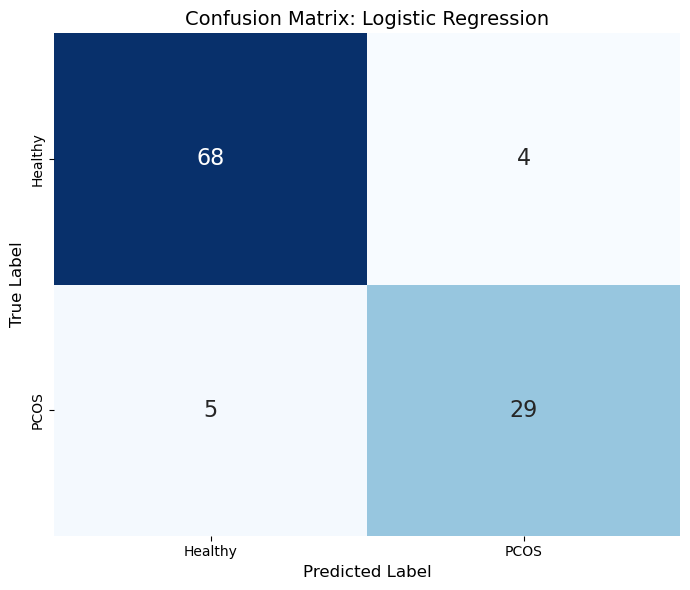

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Feature Scaling (Essential for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# 3. Generate Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# 4. Visualization
plt.figure(figsize=(7, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy', 'PCOS'], 
            yticklabels=['Healthy', 'PCOS'],
            annot_kws={"size": 16})

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix: Logistic Regression', fontsize=14)
plt.tight_layout()
plt.show()

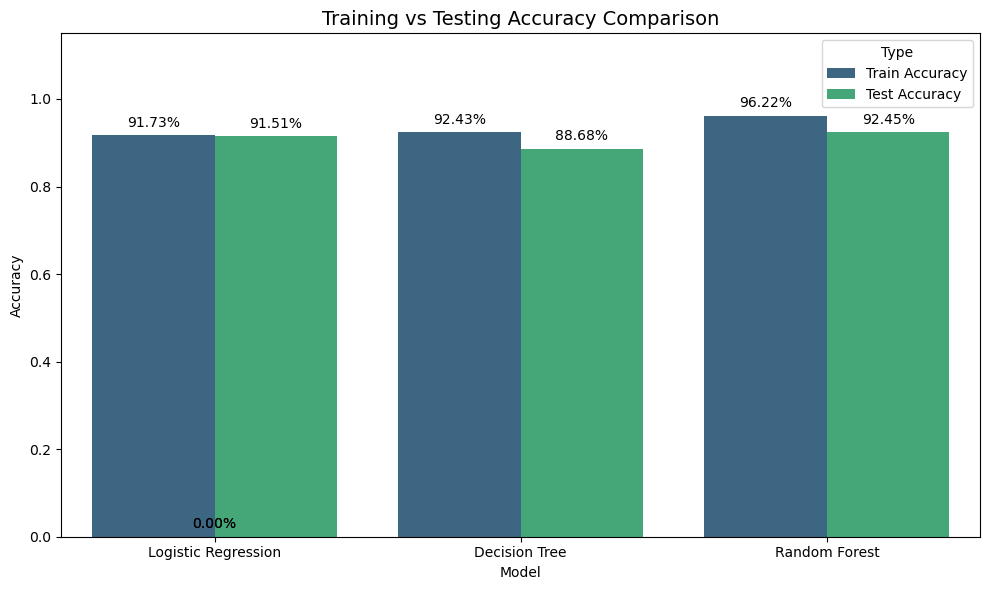

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Assuming models (lr, dt, rf) were already trained as per the previous steps
# Preparing the results data
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Train Accuracy': [
        accuracy_score(y_train, lr_model.predict(X_train_scaled)),
        accuracy_score(y_train, dt_model.predict(X_train)),
        accuracy_score(y_train, rf_model.predict(X_train))
    ],
    'Test Accuracy': [
        accuracy_score(y_test,lr_preds),
        accuracy_score(y_test, dt_preds),
        accuracy_score(y_test, rf_preds)
    ]
}

# Convert to DataFrame and melt for grouped bar chart
results_df = pd.DataFrame(results)
results_melted = results_df.melt(id_vars='Model', var_name='Type', value_name='Accuracy')

# Plotting the comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=results_melted, x='Model', y='Accuracy', hue='Type', palette='viridis')

# Adding percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

plt.title('Training vs Testing Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0, 1.15) # Adjusting limit to leave space for labels
plt.tight_layout()
plt.show()

In [45]:
# 4. Create a Sample Data Point for Testing
# This patient shows common markers: high follicle count, AMH, and metabolic symptoms
sample_patient = {
    'Follicle No. (R)': 12,
    'Follicle No. (L)': 11,
    'Skin darkening (Y/N)': 1,
    'hair growth(Y/N)': 1,
    'Weight gain(Y/N)': 1,
    'AMH(ng/mL)': 7.5,
    'Cycle(R/I)': 4,
    'Cycle length(days)': 5,
    'Fast food (Y/N)': 1,
    'LH(mIU/mL)': 1.5,
    'FSH/LH': 2.1,
    'Age (yrs)': 28,
    'BMI': 26.5,
    'Hip(inch)': 38
}

# Convert sample into a DataFrame and ensure columns match X exactly
new_case = pd.DataFrame([sample_patient])[X.columns]
#new_case_scaled = scaler.transform(new_case)

# 5. Predict the Result
prediction = rf_model.predict(new_case)[0]
probability = rf_model.predict_proba(new_case)[0]

# 6. Final Results
status = "PCOS Detected" if prediction == 1 else "Healthy / No PCOS"
print(f"--- Diagnostic Trial Result ---")
print(f"Prediction: {status}")
print(f"Confidence Level: {np.max(probability) * 100:.2f}%")

--- Diagnostic Trial Result ---
Prediction: PCOS Detected
Confidence Level: 97.63%


# Final Conclusion
Among all models, Random Forest performed the best with the highest test accuracy (92.45%), capturing complex patterns effectively.
Logistic Regression showed nearly similar performance with excellent stability and no overfitting, making it a strong interpretable alternative.
The Decision Tree slightly overfitted and gave lower test accuracy, so it was not preferred.
Overall, Random Forest is selected as the final model due to its superior predictive performance.

# Saving the model into PKL file

In [ ]:
import pickle

# Save model
with open("rf_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model saved successfully using pickle!")